**Eight notebooks** cover the workflow sequence:
1. [create_datasets_yf.ipynb](01_create_datasets_yf.ipynb) : creates datasets using yfinance
2. [sentiment_feature_building](02_sentiment_feature_building.ipynb): (optional) we calculate the sentiment using finbert on financial news
3. [feature_engineering_yf](03_feature_engineering_yf.ipynb): we compute features from data to later feed into the model
4. `optimizing_xgboost`(this notebook): we train a xgboost model to predict returns
5. [evaluate_xgboost](05_evaluate_xgboost.ipynb): we compare the cross-validation performance using various metrics to select the best model. 
6. [model_interpretation](06_model_interpretation.ipynb): we take a closer look at the drivers behind the best model's predictions.
7. [making_out_of_sample_predictions](07_making_out_of_sample_predictions.ipynb): we predict returns for our out-of-sample period
8. [backtest_backtrader](08_backtest_backtrader.ipynb): evaluate the historical performance of our strategy based on our predictive signals

In [1]:
%matplotlib inline

from pathlib import Path
import sys, os
from time import time
from tqdm import tqdm

from collections import defaultdict
from itertools import product

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from utils import MultipleTimeSeriesCV, format_time

In [4]:
YEAR = 252
np.random.seed(42)
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [5]:
results_path = Path('results')
if not results_path.exists():
    results_path.mkdir()
    
checkpoint_path = results_path / 'logs'

## Create a stock return series to predict asset price moves

In [6]:
DATA_FILE = '../data/data_features.h5'
data = pd.read_hdf(DATA_FILE, 'model_data').dropna().sort_index()

### Filter the top most-traded stocks

In [7]:
print('size before filter',len(data.index.get_level_values('symbol').unique()))
data = data[data['dollar_vol_rank'] <= 100]
print('size before filter',len(data.index.get_level_values('symbol').unique()))

size before filter 930
size before filter 305


In [8]:
DO_SENTIMENT = False

if DO_SENTIMENT:
    features = data
    # take sentiment data
    df_sentiment = pd.read_csv("../data/sentiment/sentiment_scores.csv", parse_dates=["date"])
    # remove multiindex before merging with sentiment
    features.reset_index(inplace=True)
    # take sentiment
    df_sentiment = pd.read_csv("../data/sentiment/sentiment_scores.csv", parse_dates=["date"])
    # merge with sentiment
    data = pd.merge(features, df_sentiment, left_on=['date', 'symbol'], right_on=['date', 'ticker'], how='left')
    # drop the duplicate ticker column after merging
    data.drop(columns=['ticker'], inplace=True)
    # set back the indices
    features.set_index(['date', 'symbol'], inplace=True)
    data.set_index(['date', 'symbol'], inplace=True)


data.head()


dollar_vol  dollar_vol_rank        rsi   bb_high    bb_low  \
symbol date                                                                     
AAL    2009-09-17  205.125750             98.0  80.582819 -0.089409  0.403749   
       2009-09-18   65.253740             96.0  75.979060 -0.010781  0.394179   
       2009-09-21  116.809369             91.0  79.721915 -0.042045  0.429876   
       2009-09-22   70.920847             83.0  74.188978  0.031599  0.416301   
       2009-09-23  203.157389             75.0  58.632069  0.158298  0.356458   

                        NATR       ATR        PPO      MACD  sector  ...  \
symbol date                                                          ...   
AAL    2009-09-17   9.389343 -1.024610   9.166479  0.495564       1  ...   
       2009-09-18   9.574642 -1.030085  11.503150  0.553229       1  ...   
       2009-09-21   9.277389 -0.999705  14.042266  0.638076       1  ...   
       2009-09-22   9.640853 -0.999192  15.906988  0.676326       1  ...   
       2009-09-23  11.247750 -0.994478  16.516863  0.625120       1  ...   

                   r10q_sector  r21q_sector  r42q_sector  r63q_sector  \
symbol date                                                             
AAL    2009-09-17          4.0          4.0          4.0          4.0   
       2009-09-18          4.0          4.0          4.0          4.0   
       2009-09-21          4.0          4.0          4.0          4.0   
       2009-09-22          4.0          4.0          4.0          4.0   
       2009-09-23          4.0          4.0          4.0          4.0   

                    r01_fwd   r05_fwd   r21_fwd  year  month  weekday  
symbol date                                                            
AAL    2009-09-17 -0.029240 -0.042885 -0.163743  2009      9        3  
       2009-09-18  0.090362 -0.004016 -0.160642  2009      9        4  
       2009-09-21 -0.036833 -0.090240 -0.198895  2009      9        0  
       2009-09-22 -0.135755 -0.068834 -0.260038  2009      9        1  
       2009-09-23  0.086283  0.039823 -0.146018  2009      9        2  

[5 rows x 34 columns]

In [9]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 381294 entries, ('AAL', Timestamp('2009-09-17 00:00:00')) to ('ZION', Timestamp('2023-04-11 00:00:00'))
Data columns (total 34 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   dollar_vol       381294 non-null  float64
 1   dollar_vol_rank  381294 non-null  float64
 2   rsi              381294 non-null  float64
 3   bb_high          381294 non-null  float64
 4   bb_low           381294 non-null  float64
 5   NATR             381294 non-null  float64
 6   ATR              381294 non-null  float64
 7   PPO              381294 non-null  float64
 8   MACD             381294 non-null  float64
 9   sector           381294 non-null  int64  
 10  r01              381294 non-null  float64
 11  r05              381294 non-null  float64
 12  r10              381294 non-null  float64
 13  r21              381294 non-null  float64
 14  r42              381294 non-null  float64
 15  r63      

## Model Selection: Lookback, lookahead and roll-forward periods

In [10]:
labels = data.filter(like='fwd').columns.tolist()
features = data.columns.difference(labels).tolist() # features are columns not containing '_fwd'
labels

['r01_fwd', 'r05_fwd', 'r21_fwd']

In [11]:
lookahead = 1
#label = f'r{lookahead:02}_fwd'

In [12]:
# END_DATE = '2025'
# X_cv = data.loc[idx[:, :END_DATE], :].drop(labels, axis=1)
# y_cv = data.loc[idx[:, :END_DATE], label]

In [13]:
# dates_tmp = X_cv.index.get_level_values('date').unique()
# print(f'dates ranging from {dates_tmp.min()} to {dates_tmp.max()}')

In [14]:
#print('number of tickers',len(X_cv.index.get_level_values('symbol').unique()))

In [15]:
# Define parameters for CV
train_years = 8
test_years = 6
print(f'train years {train_years}, test years {test_years}')
n_splits = 12
train_period_length=21 * 12 * train_years
test_period_length=21 * test_years

train years 8, test years 6


In [16]:
# cv = MultipleTimeSeriesCV(n_splits=n_splits,
#                           train_period_length=train_period_length,
#                           test_period_length=test_period_length,
#                           lookahead=lookahead)

In [17]:
# for testing
#train_lengths = [int(4.5 * 252), 252]
train_lengths = [int(4.5 * 252)]
test_lengths = [63, 21]
lookaheads = [1,5,21]
categoricals = ['year', 'month', 'sector', 'weekday']
param_grid = list(product(lookaheads, train_lengths, test_lengths))
#np.random.shuffle(param_grid)


In [18]:
def get_train_valid_data(X, y, train_idx, test_idx):
    x_train, y_train = X.iloc[train_idx, :], y.iloc[train_idx]
    x_val, y_val = X.iloc[test_idx, :], y.iloc[test_idx]
    return x_train, y_train, x_val, y_val

## Baseline: Linear Regression

In [19]:
#X_cv.columns

In [20]:
lr = LinearRegression()

In [21]:
lr_metrics = []

# iterate over our three CV configuration parameters
for lookahead, train_length, test_length in tqdm(param_grid):
    label = f'r{lookahead:02}_fwd'
    df = pd.get_dummies(data.loc[:, features + [label]].dropna(), 
                        columns=categoricals, 
                        drop_first=True)
    X, y = df.drop(label, axis=1), df[label]

    n_splits = int(2 * YEAR / test_length)
    cv = MultipleTimeSeriesCV(n_splits=n_splits,
                              test_period_length=test_length,
                              lookahead=lookahead,
                              train_period_length=train_length)

    ic, preds = [], []
    for i, (train_idx, test_idx) in enumerate(cv.split(X=X)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)
        preds.append(y_test.to_frame('y_true').assign(y_pred=y_pred))
        ic.append(spearmanr(y_test, y_pred)[0])
    preds = pd.concat(preds)
    lr_metrics.append([lookahead, 
                       train_length, 
                       test_length,
                       np.mean(ic),
                       spearmanr(preds.y_true, preds.y_pred)[0]
                      ])

columns = ['lookahead', 'train_length', 'test_length', 'ic_by_day', 'ic']
lr_metrics = pd.DataFrame(lr_metrics, columns=columns)

100%|██████████| 6/6 [00:11<00:00,  1.99s/it]


In [22]:
lr_store = Path(results_path / 'tuning_lr.parquet')
lr_metrics.to_parquet(lr_store, index=False)

### Information Coefficient - Distribution by Lookahead

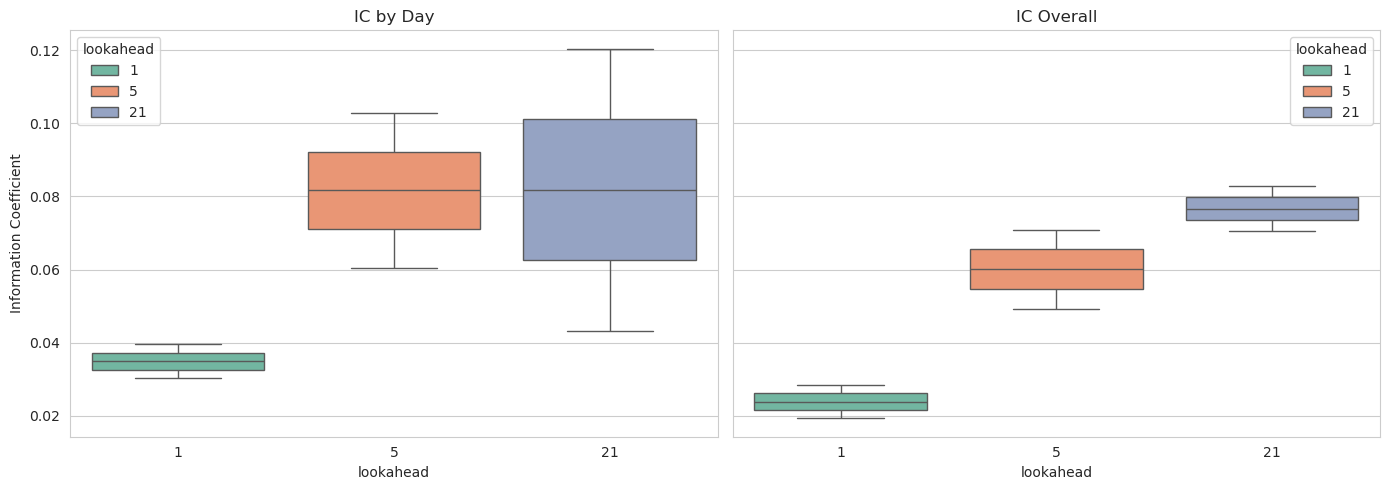

In [23]:
fig, axes = plt.subplots(ncols=2, figsize=(14,5), sharey=True)

# plot average of daily IC values
sns.boxplot(x='lookahead', y='ic_by_day',data=lr_metrics, ax=axes[0], palette='Set2', hue='lookahead')
axes[0].set_title('IC by Day')

# plot IC across all predictions
sns.boxplot(x='lookahead', y='ic',data=lr_metrics, ax=axes[1], palette='Set2',  hue='lookahead')
axes[1].set_title('IC Overall')
axes[0].set_ylabel('Information Coefficient')
axes[1].set_ylabel('')
fig.tight_layout()

### Best Train/Test Period Lengths

In [24]:
(lr_metrics.groupby('lookahead', group_keys=False)
 .apply(lambda x: x.nlargest(3, 'ic_by_day')))

,lookahead,train_length,test_length,ic_by_day,ic
0,1,1134,63,0.039562,0.028364
1,1,1134,21,0.030309,0.019324
2,5,1134,63,0.102821,0.070936
3,5,1134,21,0.060496,0.049234
4,21,1134,63,0.120372,0.082843
5,21,1134,21,0.043271,0.070479


### XGBoost Model

The notebook example iterates over many configurations, optionally using random samples to speed up model selection using a diverse subset. The goal is to identify the most impactful parameters without trying every possible combination.

In [25]:
def get_fi(model):
    """Return normalized feature importance as pd.Series (using gain)"""
    score = model.get_score(importance_type='gain')
    fi = pd.Series(score)
    return fi / fi.sum()

### Hyperparameters

The base parameters are not affected by cross-validation

In [26]:
base_params = dict(booster='gbtree',
                   objective='reg:squarederror',
                   verbosity=0)

We choose the following parameters and values to select our best model

In [27]:
# # constraints on structure (depth) of each tree
max_depths_opts = [2, 3, 5]
# num_leaves_opts = [2 ** i for i in max_depths]
# min_data_in_leaf_opts = [250, 500, 1000]
n_estimators_opts = [100, 300, 500]
alpha_opts = [0, 1, 10]

# # weight of each new tree in the ensemble
#learning_rate_opts = [.01, .1, .3]
learning_rate_opts = [.01, .1]
# # random feature selection
# feature_fraction_opts = [.3, .6, .95]

In [28]:
param_names = ['learning_rate', 'max_depth', 'n_estimators', 'alpha']

In [29]:
cv_params = list(product(learning_rate_opts,
                         max_depths_opts,
                         n_estimators_opts,
                         alpha_opts))
n_params = len(cv_params)
print(f'# Parameters: {n_params}')

# Parameters: 54


### Train/Test period lengths

In [30]:
lookaheads = [1, 5, 21]
label_dict = dict(zip(lookaheads, labels))

In [31]:
#train_lengths = [int(4.5 * 252), int(8 * 252)]
#train_lengths = [int(4.5 * 252), 252]
train_lengths = [int(4.5 * 252)]
test_lengths = [63, 21]


In [32]:
test_params = list(product(lookaheads, train_lengths, test_lengths))
n = len(test_params)
test_param_sample = np.random.choice(list(range(n)), size=int(n), replace=False)
test_params = [test_params[i] for i in test_param_sample]
print('Train configs:', len(test_params))

Train configs: 6


### Categorical variables

We integer-encode categorical variables with values starting at zero, as expected by LightGBM (not necessary
as long as the category codes have values less than $2^{32}$, but avoids a warning)

In [33]:
categoricals = ['year', 'weekday', 'month']
for feature in categoricals:
    data[feature] = pd.factorize(data[feature], sort=True)[0]

### Custom Loss Function: Information Coefficient

In [34]:
def ic_xgb(preds, dtrain):
    """Custom IC eval metric for xgboost"""
    labels = dtrain.get_label()
    ic_value = spearmanr(preds, labels)[0]
    return 'ic', ic_value

### Run Cross-Validation

To explore the hyperparameter space, we specify values for key parameters that we would like to test in combination. The sklearn library supports `RandomizedSearchCV` to cross-validate a subset of parameter combinations that are sampled randomly from specified distributions. We will implement a custom version that allows us to monitor performance so we can abort the search process once we're satisfied with the result, rather than specifying a set number of iterations beforehand.

In [35]:
xgb_store = Path(results_path / 'tuning_xgb.h5')

In [36]:
labels = sorted(data.filter(like='fwd').columns)
features = data.columns.difference(labels).tolist()

In [37]:
label_dict = dict(zip(lookaheads, labels))

In [38]:
#num_iterations = [10, 25, 50, 75] + list(range(100, 501, 50))
#num_iterations = [10, 25, 50, 75] + list(range(100, 301, 100))
num_iterations = [10, 50, 100]
num_boost_round = num_iterations[-1]

In [39]:
metric_cols = (param_names + ['t', 'daily_ic_mean', 'daily_ic_mean_n',
                              'daily_ic_median', 'daily_ic_median_n'] +
               [str(n) for n in num_iterations])

In [40]:
metric_cols

['learning_rate',
 'max_depth',
 'n_estimators',
 'alpha',
 't',
 'daily_ic_mean',
 'daily_ic_mean_n',
 'daily_ic_median',
 'daily_ic_median_n',
 '10',
 '50',
 '100']

In [ ]:
# TESTING LOSSES
for lookahead, train_length, test_length in test_params:
    # randomized grid search
    cvp = np.random.choice(list(range(n_params)),
                           size=int(n_params / 2),
                           replace=False)
    cv_params_ = [cv_params[i] for i in cvp]

    # set up cross-validation
    n_splits = int(2 * YEAR / test_length)
    print(f'Lookahead: {lookahead:2.0f} | '
          f'Train: {train_length:3.0f} | '
          f'Test: {test_length:2.0f} | '
          f'Params: {len(cv_params_):3.0f} | '
          f'Train configs: {len(test_params)}')

    # time-series cross-validation
    cv = MultipleTimeSeriesCV(n_splits=n_splits,
                              lookahead=lookahead,
                              test_period_length=test_length,
                              train_period_length=train_length)

    label = label_dict[lookahead]
    outcome_data = data.loc[:, features + [label]].dropna()
    
    # XGBoost requires separate X and y
    X = outcome_data.drop(label, axis=1)
    y = outcome_data[label]
    
    T = 0
    predictions, metrics, feature_importance, daily_ic = [], [], [], []
    
    # iterate over (shuffled) hyperparameter combinations
    for p, param_vals in enumerate(cv_params_):
        key = f'{lookahead}/{train_length}/{test_length}/' + '/'.join([str(p) for p in param_vals])
        params = dict(zip(param_names, param_vals))
        params.update(base_params)

        start = time()
        cv_preds, nrounds = [], []
        ic_cv = defaultdict(list)
        
        # iterate over folds
        for i, (train_idx, test_idx) in enumerate(cv.split(X=outcome_data)):
            
            # select train subset
            X_train = X.iloc[train_idx]
            y_train = y.iloc[train_idx]
            
            # capture predictions
            test_set = outcome_data.iloc[test_idx, :]
            X_test = test_set.drop(label, axis=1)
            y_test = test_set[label]
            


            # Convert to DMatrix for faster training
            dtrain = xgb.DMatrix(X_train, label=y_train)
            # Convert to DMatrix for prediction
            dtest = xgb.DMatrix(X_test, label=y_test)
            
            # Set up evaluation list for tracking
            evallist = [(dtrain, 'train'), (dtest, 'eval')]
            
            # Dictionary to store evaluation results
            evals_result = {}
            # train model for num_boost_round
            model = xgb.train(params=params,
                              dtrain=dtrain,
                              num_boost_round=num_boost_round, # instead of retraining for every boosting round, train once (up to num_boost_round rounds), and then slice predictions from the trained model.
                              feval=ic_xgb, # custom loss function, XGBoost will still optimize based on the objective function (e.g., 'reg:squarederror'), but it will report your custom IC during training.
                              # but we can use it for early stopping, model comparison, and logging
                              evals=evallist,  # track both training and validation loss
                              evals_result=evals_result,  # store the results
                              #early_stopping_rounds=50,
                              #verbose_eval=50)
                              verbose_eval=False)
            
            # Store loss curves for analysis
            #train_loss = evals_result['train'][params.get('objective', 'reg:squarederror')]
            #valid_loss = evals_result['eval'][params.get('objective', 'reg:squarederror')]
            # use ic instead
            train_loss = evals_result['train']['ic']
            valid_loss = evals_result['eval']['ic']

            # Calculate overfitting metrics
            min_valid_loss_idx = np.argmin(valid_loss)
            min_valid_loss = valid_loss[min_valid_loss_idx]
            final_train_loss = train_loss[min_valid_loss_idx]
            overfitting_ratio = (min_valid_loss - final_train_loss) / final_train_loss
    
            # Store loss information
            loss_info = {
                'fold': i,
                'min_valid_loss': min_valid_loss,
                'final_train_loss': final_train_loss,
                'overfitting_ratio': overfitting_ratio,
                'best_iteration': min_valid_loss_idx + 1,
                'train_loss_curve': train_loss,
                'valid_loss_curve': valid_loss
            }

            # log feature importance and loss
            if i == 0:
                #fi = pd.Series(model.get_score(importance_type='gain')).to_frame()
                fi = get_fi(model).to_frame()
                fold_losses = [loss_info]
            else:
                #fi[i] = pd.Series(model.get_score(importance_type='gain'))
                fi[i] = get_fi(model)
                fold_losses.append(loss_info)


            
            # Get predictions for different iteration counts
            y_pred = {str(n): model.predict(dtest, iteration_range=(0, n)) for n in num_iterations}
            
            # record predictions for each fold
            cv_preds.append(y_test.to_frame('y_test').assign(**y_pred).assign(i=i))
        
        
        # combine fold results
        cv_preds = pd.concat(cv_preds).assign(**params)
        predictions.append(cv_preds)
        
        # aggregate loss metrics for all the folds
        avg_overfitting_ratio = np.mean([fold['overfitting_ratio'] for fold in fold_losses])
        avg_best_iteration = np.mean([fold['best_iteration'] for fold in fold_losses])
        avg_final_train_loss =  np.mean([fold['final_train_loss'] for fold in fold_losses])
        avg_final_valid_loss = np.mean([fold['min_valid_loss'] for fold in fold_losses])


        additional_metrics = {
        'avg_overfitting_ratio': avg_overfitting_ratio,
        'avg_best_iteration': avg_best_iteration,
        'final_train_loss': avg_final_train_loss,
        'final_valid_loss': avg_final_valid_loss
        }   

        # compute IC per day
        by_day = cv_preds.groupby(level='date')
        ic_by_day = pd.concat([by_day.apply(lambda x: spearmanr(x.y_test, x[str(n)])[0]).to_frame(n)
                               for n in num_iterations], axis=1)
        daily_ic_mean = ic_by_day.mean()
        daily_ic_mean_n = daily_ic_mean.idxmax()
        daily_ic_median = ic_by_day.median()
        daily_ic_median_n = daily_ic_median.idxmax()
        
        # compute IC across all predictions
        ic = [spearmanr(cv_preds.y_test, cv_preds[str(n)])[0] for n in num_iterations]
        t = time() - start
        T += t
        
        # collect metrics
        metrics = pd.Series(list(param_vals) +
                            [t, daily_ic_mean.max(), daily_ic_mean_n, daily_ic_median.max(), daily_ic_median_n] +
                            ic + list(additional_metrics.values()),
                            index=metric_cols + list(additional_metrics.keys()))
        msg = f'\t{p:3.0f} | {format_time(T)} ({t:3.0f}) | {params["learning_rate"]:5.2f} | '
        #msg += f'{params["max_depth"]:3.0f} | {params["colsample_bytree"]:3.0%} | {params["min_child_weight"]:4.0f} | '
        msg += f'{params["max_depth"]:3.0f} | '
        msg += f' {max(ic):6.2%} | {ic_by_day.mean().max(): 6.2%} | {daily_ic_mean_n: 4.0f} | {ic_by_day.median().max(): 6.2%} | {daily_ic_median_n: 4.0f}'
        msg += f' {avg_final_train_loss: 5.2f} | {avg_final_valid_loss: 5.2f}'
        print(msg)

        # Store loss curves for detailed analysis
        # loss_curves_df = pd.DataFrame({
        #     'fold': [fold['fold'] for fold in fold_losses],
        #     'train_loss_curves': [fold['train_loss_curve'] for fold in fold_losses],
        #     'valid_loss_curves': [fold['valid_loss_curve'] for fold in fold_losses],
        #     **params
        # })

        # persist results for given CV run and hyperparameter combination
        metrics.to_hdf(xgb_store, 'metrics/' + key)
        ic_by_day.assign(**params).to_hdf(xgb_store, 'daily_ic/' + key)
        fi.T.describe().T.assign(**params).to_hdf(xgb_store, 'fi/' + key)
        cv_preds.to_hdf(xgb_store, 'predictions/' + key)
        # Keep loss information
        #loss_curves_df.to_hdf(xgb_store, 'loss_curves/' + key)

Lookahead:  1 | Train: 1134 | Test: 63 | Params:  27 | Train configs: 6


	  0 | 00:00:29 ( 29) |  0.01 |   2 |  -0.85% |  0.27% |   10 |  0.04% |   50  0.04 | -0.03
	  1 | 00:01:04 ( 35) |  0.01 |   2 |  -1.76% | -0.74% |   50 | -0.45% |   50  0.05 | -0.04
	  2 | 00:01:34 ( 31) |  0.10 |   3 |   0.36% |  0.20% |   10 |  0.11% |  100  0.08 | -0.04
	  3 | 00:02:08 ( 34) |  0.10 |   5 |   1.09% |  0.51% |  100 |  0.80% |   50  0.09 | -0.05
	  4 | 00:02:51 ( 43) |  0.01 |   3 |  -0.30% |  0.37% |  100 |  0.53% |   50  0.06 | -0.03
	  5 | 00:03:31 ( 40) |  0.01 |   2 |  -0.87% |  0.13% |  100 | -0.03% |  100  0.04 | -0.03
	  6 | 00:04:10 ( 39) |  0.10 |   2 |  -0.89% |  0.29% |   10 |  0.10% |   10  0.07 | -0.04
	  7 | 00:04:45 ( 35) |  0.10 |   5 |   1.09% |  0.51% |  100 |  0.80% |   50  0.09 | -0.05
	  8 | 00:05:27 ( 42) |  0.01 |   3 |  -0.28% |  0.43% |   10 |  0.22% |   10  0.05 | -0.03
	  9 | 00:06:06 ( 40) |  0.10 |   2 |  -0.35% |  0.02% |   10 |  0.22% |   10  0.07 | -0.04
	 10 | 00:06:43 ( 37) |  0.10 |   5 |   1.12% |  0.34% |  100 |  0.41% |   50  0

In [42]:
# for lookahead, train_length, test_length in test_params:
#     # randomized grid search
#     cvp = np.random.choice(list(range(n_params)),
#                            size=int(n_params / 2),
#                            replace=False)
#     cv_params_ = [cv_params[i] for i in cvp]

#     # set up cross-validation
#     n_splits = int(2 * YEAR / test_length)
#     print(f'Lookahead: {lookahead:2.0f} | '
#           f'Train: {train_length:3.0f} | '
#           f'Test: {test_length:2.0f} | '
#           f'Params: {len(cv_params_):3.0f} | '
#           f'Train configs: {len(test_params)}')

#     # time-series cross-validation
#     cv = MultipleTimeSeriesCV(n_splits=n_splits,
#                               lookahead=lookahead,
#                               test_period_length=test_length,
#                               train_period_length=train_length)

#     label = label_dict[lookahead]
#     outcome_data = data.loc[:, features + [label]].dropna()
    
#     # XGBoost requires separate X and y
#     X = outcome_data.drop(label, axis=1)
#     y = outcome_data[label]
    
#     T = 0
#     predictions, metrics, feature_importance, daily_ic = [], [], [], []
    
#     # iterate over (shuffled) hyperparameter combinations
#     for p, param_vals in enumerate(cv_params_):
#         key = f'{lookahead}/{train_length}/{test_length}/' + '/'.join([str(p) for p in param_vals])
#         params = dict(zip(param_names, param_vals))
#         params.update(base_params)

#         start = time()
#         cv_preds, nrounds = [], []
#         ic_cv = defaultdict(list)
        
#         # iterate over folds
#         for i, (train_idx, test_idx) in enumerate(cv.split(X=outcome_data)):
            
#             # select train subset
#             X_train = X.iloc[train_idx]
#             y_train = y.iloc[train_idx]
            
#             # Convert to DMatrix for faster training
#             dtrain = xgb.DMatrix(X_train, label=y_train)
            
#             # Create categorical feature list if needed
#             #if categoricals:
#             #    dtrain.set_feature_types({col: 'c' for col in categoricals})
            
#             # train model for num_boost_round
#             model = xgb.train(params=params,
#                               dtrain=dtrain,
#                               num_boost_round=num_boost_round, # instead of retraining for every boosting round, train once (up to num_boost_round rounds), and then slice predictions from the trained model.
#                               feval=ic_xgb, # custom loss function, XGBoost will still optimize based on the objective function (e.g., 'reg:squarederror'), but it will report your custom IC during training.
#                               # but we can use it for early stopping, model comparison, and logging
#                               early_stopping_rounds=50,
#                               verbose_eval=10)
#                               #verbose_eval=False)
            
#             # log feature importance
#             if i == 0:
#                 #fi = pd.Series(model.get_score(importance_type='gain')).to_frame()
#                 fi = get_fi(model).to_frame()
#             else:
#                 #fi[i] = pd.Series(model.get_score(importance_type='gain'))
#                 fi[i] = get_fi(model)

#             # capture predictions
#             test_set = outcome_data.iloc[test_idx, :]
#             X_test = test_set.drop(label, axis=1)
#             y_test = test_set[label]
            
#             # Convert to DMatrix for prediction
#             dtest = xgb.DMatrix(X_test)
            
#             # Get predictions for different iteration counts
#             y_pred = {str(n): model.predict(dtest, iteration_range=(0, n)) for n in num_iterations}
            
#             # record predictions for each fold
#             cv_preds.append(y_test.to_frame('y_test').assign(**y_pred).assign(i=i))
        
#         # combine fold results
#         cv_preds = pd.concat(cv_preds).assign(**params)
#         predictions.append(cv_preds)
        
#         # compute IC per day
#         by_day = cv_preds.groupby(level='date')
#         ic_by_day = pd.concat([by_day.apply(lambda x: spearmanr(x.y_test, x[str(n)])[0]).to_frame(n)
#                                for n in num_iterations], axis=1)
#         daily_ic_mean = ic_by_day.mean()
#         daily_ic_mean_n = daily_ic_mean.idxmax()
#         daily_ic_median = ic_by_day.median()
#         daily_ic_median_n = daily_ic_median.idxmax()
        
#         # compute IC across all predictions
#         ic = [spearmanr(cv_preds.y_test, cv_preds[str(n)])[0] for n in num_iterations]
#         t = time() - start
#         T += t
        
#         # collect metrics
#         metrics = pd.Series(list(param_vals) +
#                             [t, daily_ic_mean.max(), daily_ic_mean_n, daily_ic_median.max(), daily_ic_median_n] + ic,
#                             index=metric_cols)
#         msg = f'\t{p:3.0f} | {format_time(T)} ({t:3.0f}) | {params["learning_rate"]:5.2f} | '
#         #msg += f'{params["max_depth"]:3.0f} | {params["colsample_bytree"]:3.0%} | {params["min_child_weight"]:4.0f} | '
#         msg += f'{params["max_depth"]:3.0f} | '
#         msg += f' {max(ic):6.2%} | {ic_by_day.mean().max(): 6.2%} | {daily_ic_mean_n: 4.0f} | {ic_by_day.median().max(): 6.2%} | {daily_ic_median_n: 4.0f}'
#         print(msg)

#         # persist results for given CV run and hyperparameter combination
#         metrics.to_hdf(xgb_store, 'metrics/' + key)
#         ic_by_day.assign(**params).to_hdf(xgb_store, 'daily_ic/' + key)
#         fi.T.describe().T.assign(**params).to_hdf(xgb_store, 'fi/' + key)
#         cv_preds.to_hdf(xgb_store, 'predictions/' + key)

In [43]:
xgb_store

PosixPath('results/tuning_xgb.h5')

In [44]:
metrics

learning_rate              0.010000
max_depth                  5.000000
n_estimators             300.000000
alpha                      0.000000
t                         94.557696
daily_ic_mean             -0.002379
daily_ic_mean_n           10.000000
daily_ic_median           -0.005607
daily_ic_median_n        100.000000
10                        -0.076163
50                        -0.063347
100                       -0.056920
avg_overfitting_ratio     -1.128618
avg_best_iteration        26.208333
final_train_loss           0.155314
final_valid_loss          -0.020336
dtype: float64